# Exploratory Data Analysis & Business Insights

## Objective

Analyze business performance across revenue, orders, customers, products, regions, freight, and delivery operations to identify meaningful growth patterns and potential business concerns before introducing the profitability layer.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(
    "../data/processed/cleaned_order_items.csv",
    parse_dates=["order_purchase_timestamp"]
)

df.head()

,order_id,order_item_id,customer_unique_id,order_purchase_timestamp,purchase_year,purchase_month,purchase_year_month,customer_city,customer_state,product_id,product_category_name,seller_id,price,freight_value,freight_to_price_pct,delivery_days
0,e481f51cbdc54678b7cc49136f2d6af7,1,7c396fd4830fd04220f754e42b4e5bff,2017-10-02 10:56:33,2017,10,2017-10,sao paulo,SP,87285b34884572647811a353c7ac498a,utilidades_domesticas,3504c0cb71d7fa48d967e0e4c94d59d9,29.99,8.72,29.076359,8.0
1,53cdb2fc8bc7dce0b6741e2150273451,1,af07308b275d755c9edb36a90c618231,2018-07-24 20:41:37,2018,7,2018-07,barreiras,BA,595fac2a385ac33a80bd5114aec74eb8,perfumaria,289cdb325fb7e7f891c38608bf9e0962,118.70,22.76,19.174389,13.0
2,47770eb9100c2d0c44946d9cf07ec65d,1,3a653a41f6f9fc3d2a113cf8398680e8,2018-08-08 08:38:49,2018,8,2018-08,vianopolis,GO,aa4383b373c6aca5d8797843e5594415,automotivo,4869f7a5dfa277a7dca6462dcf3b52b2,159.90,19.22,12.020013,9.0
3,949d5b44dbf5de918fe9c16f97b45f8a,1,7c142cf63193a1473d2e66489a9ae977,2017-11-18 19:28:06,2017,11,2017-11,sao goncalo do amarante,RN,d0b61bfb1de832b15ba9d266ca96e5b0,pet_shop,66922902710d126a0e7d26b0e3805106,45.00,27.20,60.444444,13.0
4,ad21c59c0840e6cb83a9ceb5573f8159,1,72632f0f9dd73dfee390c9b22eb56dd6,2018-02-13 21:18:39,2018,2,2018-02,santo andre,SP,65266b2da20d04dbe00c5c2d3bb7859e,papelaria,2c9e548be18521d1c43cde1c582c6de8,19.90,8.72,43.819095,2.0


In [2]:
df.shape

(110197, 16)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110197 entries, 0 to 110196
Data columns (total 16 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   order_id                  110197 non-null  object        
 1   order_item_id             110197 non-null  int64         
 2   customer_unique_id        110197 non-null  object        
 3   order_purchase_timestamp  110197 non-null  datetime64[ns]
 4   purchase_year             110197 non-null  int64         
 5   purchase_month            110197 non-null  int64         
 6   purchase_year_month       110197 non-null  object        
 7   customer_city             110197 non-null  object        
 8   customer_state            110197 non-null  object        
 9   product_id                110197 non-null  object        
 10  product_category_name     110197 non-null  object        
 11  seller_id                 110197 non-null  object        
 12  pr

## 1. Overall Business Performance

In [4]:
total_revenue = df["price"].sum()
total_orders = df["order_id"].nunique()
total_customers = df["customer_unique_id"].nunique()
total_items = len(df)
total_freight = df["freight_value"].sum()

avg_order_value = (
    df.groupby("order_id")["price"].sum().mean()
)

print(f"Total Merchandise Revenue: R$ {total_revenue:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Total Customers: {total_customers:,}")
print(f"Total Item Rows: {total_items:,}")
print(f"Total Freight Value: R$ {total_freight:,.2f}")
print(f"Average Order Value: R$ {avg_order_value:,.2f}")

Total Merchandise Revenue: R$ 13,221,498.11
Total Orders: 96,478
Total Customers: 93,358
Total Item Rows: 110,197
Total Freight Value: R$ 2,198,275.64
Average Order Value: R$ 137.04


## 2. Monthly Business Performance

Analyze monthly trends in merchandise revenue, orders, and active customers to understand how the business grew over time.

In [5]:
monthly_performance = (
    df.groupby("purchase_year_month")
    .agg(
        revenue=("price", "sum"),
        orders=("order_id", "nunique"),
        customers=("customer_unique_id", "nunique")
    )
    .reset_index()
)

monthly_performance["purchase_year_month"] = pd.to_datetime(
    monthly_performance["purchase_year_month"]
)

monthly_performance

,purchase_year_month,revenue,orders,customers
0,2016-09-01,134.97,1,1
1,2016-10-01,40325.11,265,262
2,2016-12-01,10.90,1,1
3,2017-01-01,111798.36,750,718
4,2017-02-01,234223.40,1653,1630
5,2017-03-01,359198.85,2546,2508
6,2017-04-01,340669.68,2303,2274
7,2017-05-01,489338.25,3546,3479
8,2017-06-01,421923.37,3135,3076
9,2017-07-01,481604.52,3872,3802


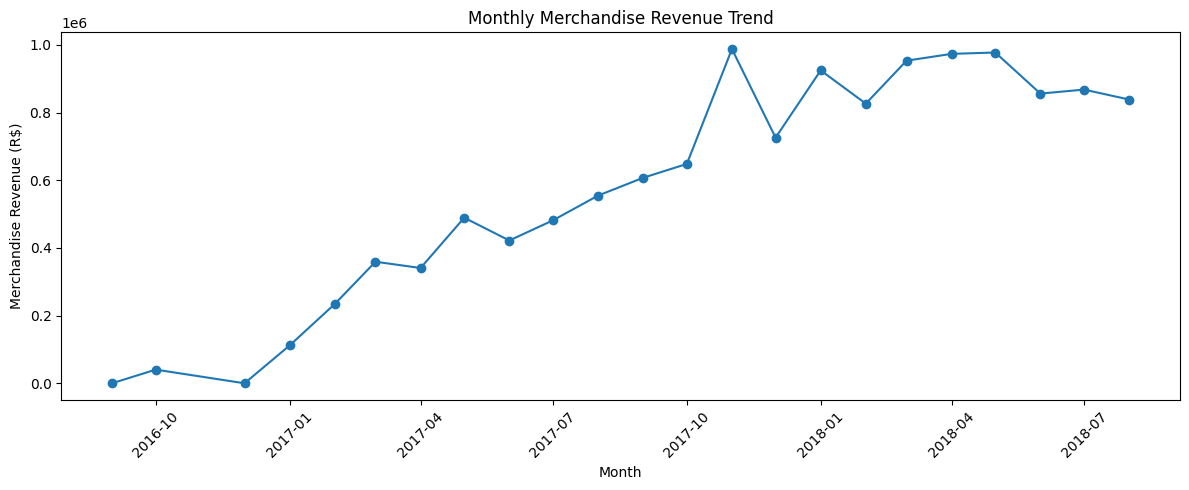

In [6]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_performance["purchase_year_month"],
    monthly_performance["revenue"],
    marker="o"
)

plt.title("Monthly Merchandise Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Merchandise Revenue (R$)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

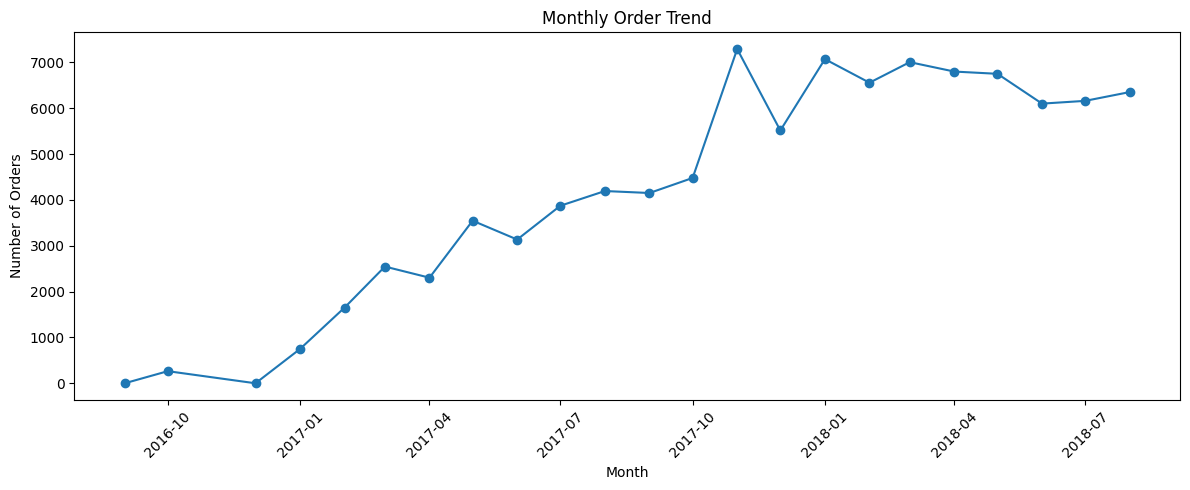

In [7]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_performance["purchase_year_month"],
    monthly_performance["orders"],
    marker="o"
)

plt.title("Monthly Order Trend")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

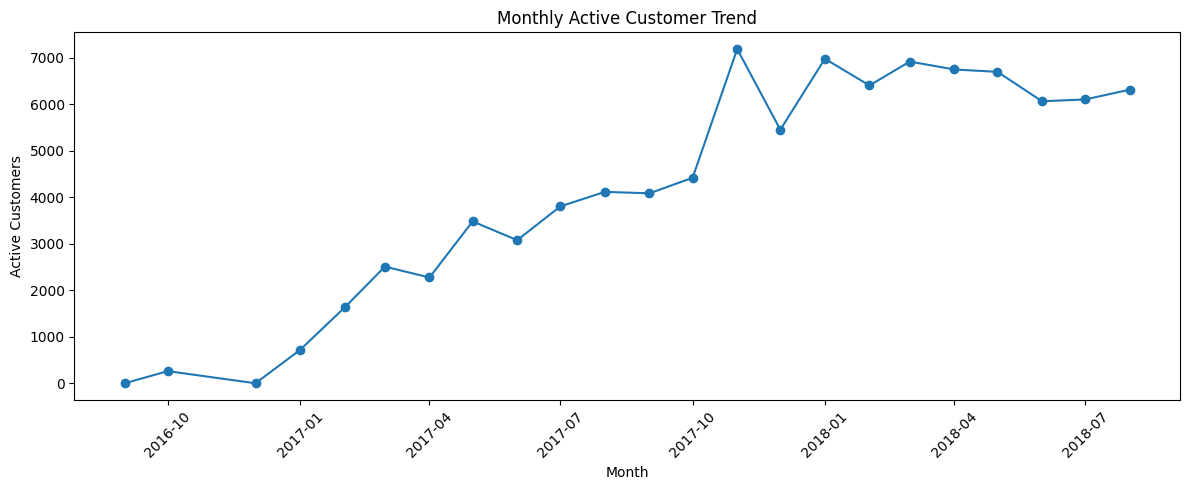

In [8]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_performance["purchase_year_month"],
    monthly_performance["customers"],
    marker="o"
)

plt.title("Monthly Active Customer Trend")
plt.xlabel("Month")
plt.ylabel("Active Customers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 3. Comparable-Period Growth Analysis

Compare January–August 2017 with January–August 2018 to measure business growth without using incomplete full-year comparisons.

In [9]:
comparable_df = df[
    (df["purchase_month"] <= 8) &
    (df["purchase_year"].isin([2017, 2018]))
].copy()

yearly_comparison = (
    comparable_df.groupby("purchase_year")
    .agg(
        revenue=("price", "sum"),
        orders=("order_id", "nunique"),
        customers=("customer_unique_id", "nunique"),
        freight=("freight_value", "sum")
    )
)

yearly_comparison

,revenue,orders,customers,freight
purchase_year,,,,
2017,2993456.13,21998,21404,479442.12
2018,7218125.12,52783,51612,1233459.65


In [10]:
growth = yearly_comparison.pct_change() * 100

growth.round(2)

,revenue,orders,customers,freight
purchase_year,,,,
2017,NaN,NaN,NaN,NaN
2018,141.13,139.94,141.13,157.27


In [11]:
yearly_comparison["avg_order_value"] = (
    yearly_comparison["revenue"]
    / yearly_comparison["orders"]
)

yearly_comparison

,revenue,orders,customers,freight,avg_order_value
purchase_year,,,,,
2017,2993456.13,21998,21404,479442.12,136.078559
2018,7218125.12,52783,51612,1233459.65,136.750945


In [12]:
aov_growth = (
    yearly_comparison.loc[2018, "avg_order_value"]
    / yearly_comparison.loc[2017, "avg_order_value"]
    - 1
) * 100

print(f"AOV Growth: {aov_growth:.2f}%")

AOV Growth: 0.49%


### Business Insight

Comparing January–August 2017 with the same period in 2018:

- Merchandise revenue increased by **141.13%**.
- Orders increased by **139.94%**.
- Active customers increased by **141.13%**.
- Freight value increased by **157.27%**, faster than merchandise revenue.
- Average order value increased by only **0.49%**.

The business therefore experienced strong volume-driven growth rather than higher customer spending per order. Revenue expansion was primarily supported by acquiring more customers and generating more orders, while average order value remained nearly unchanged.

Freight value grew faster than merchandise revenue, indicating a potential increase in logistics burden that should be investigated further during the profitability analysis.

## 4. Product Category Growth Analysis

Identify which product categories contributed most to the increase in merchandise revenue between January–August 2017 and January–August 2018.

In [13]:
category_growth = (
    comparable_df
    .groupby(["product_category_name", "purchase_year"])["price"]
    .sum()
    .unstack(fill_value=0)
    .reset_index()
)

category_growth.columns = [
    "product_category",
    "revenue_2017",
    "revenue_2018"
]

In [14]:
category_growth["incremental_revenue"] = (
    category_growth["revenue_2018"]
    - category_growth["revenue_2017"]
)

category_growth = category_growth.sort_values(
    "incremental_revenue",
    ascending=False
)

category_growth.head(10)

,product_category,revenue_2017,revenue_2018,incremental_revenue
11,beleza_saude,243521.70,755724.50,512202.80
66,relogios_presentes,201137.86,687855.20,486717.34
32,esporte_lazer,216724.33,517166.26,300441.93
44,informatica_acessorios,214631.27,496269.30,281638.03
13,cama_mesa_banho,254444.82,532358.85,277914.03
73,utilidades_domesticas,127534.54,391823.46,264288.92
8,automotivo,125247.48,343288.30,218040.82
54,moveis_decoracao,170858.58,381649.57,210790.99
9,bebes,67998.26,250615.79,182617.53
21,construcao_ferramentas_construcao,2581.49,122886.61,120305.12


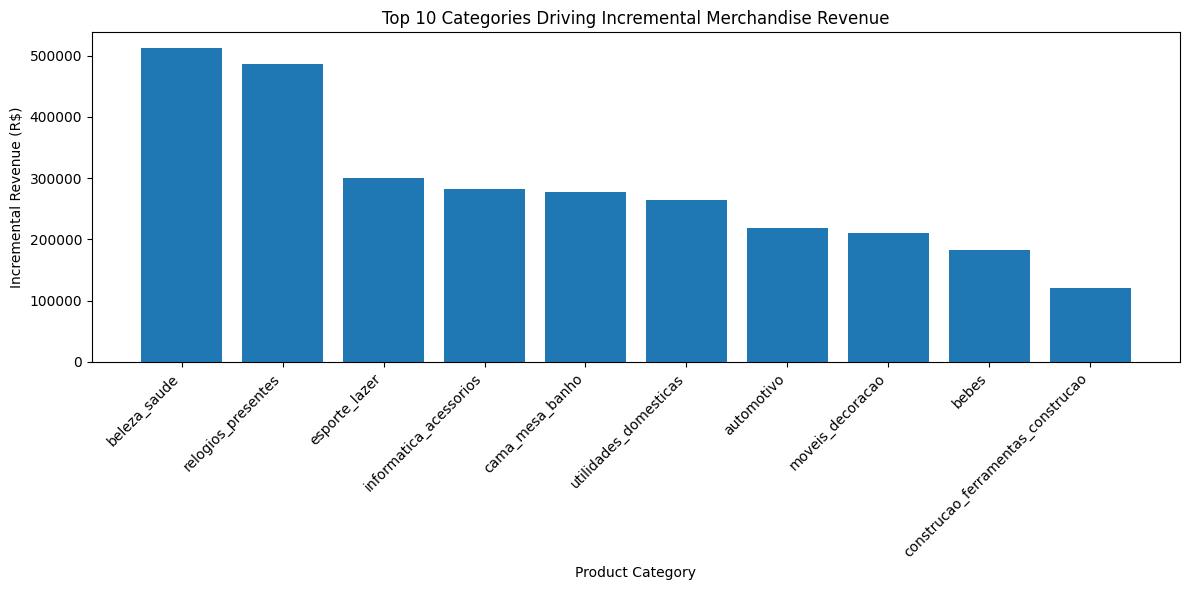

In [15]:
top_growth_categories = category_growth.head(10)

plt.figure(figsize=(12, 6))

plt.bar(
    top_growth_categories["product_category"],
    top_growth_categories["incremental_revenue"]
)

plt.title("Top 10 Categories Driving Incremental Merchandise Revenue")
plt.xlabel("Product Category")
plt.ylabel("Incremental Revenue (R$)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [16]:
total_incremental_revenue = category_growth["incremental_revenue"].sum()

top_10_incremental_revenue = (
    category_growth.head(10)["incremental_revenue"].sum()
)

top_10_growth_share = (
    top_10_incremental_revenue
    / total_incremental_revenue
    * 100
)

print(
    f"Top 10 Categories' Share of Incremental Revenue: "
    f"{top_10_growth_share:.2f}%"
)

Top 10 Categories' Share of Incremental Revenue: 67.58%


### Business Insight

The top 10 product categories contributed **67.58% of total incremental merchandise revenue** between the comparable 2017 and 2018 periods.

This indicates that business growth was moderately concentrated in a relatively small group of product categories rather than being evenly distributed across the entire product portfolio.

However, revenue growth alone does not indicate healthy growth. These categories should later be evaluated using contribution margins, freight burden, returns, and customer acquisition costs to determine whether the categories driving revenue growth are also creating economic value.

## 5. Freight Burden Analysis

Evaluate whether the product categories driving merchandise revenue growth also experienced increasing freight burden.

In [17]:
category_freight = (
    comparable_df
    .groupby(["product_category_name", "purchase_year"])
    .agg(
        revenue=("price", "sum"),
        freight=("freight_value", "sum")
    )
    .reset_index()
)

category_freight["freight_to_revenue_pct"] = (
    category_freight["freight"]
    / category_freight["revenue"]
    * 100
)

In [18]:
freight_comparison = (
    category_freight
    .pivot(
        index="product_category_name",
        columns="purchase_year",
        values="freight_to_revenue_pct"
    )
    .reset_index()
)

freight_comparison.columns = [
    "product_category",
    "freight_pct_2017",
    "freight_pct_2018"
]

freight_comparison["freight_burden_change_pp"] = (
    freight_comparison["freight_pct_2018"]
    - freight_comparison["freight_pct_2017"]
)

In [19]:
category_diagnostics = category_growth.merge(
    freight_comparison,
    on="product_category",
    how="left"
)

category_diagnostics[
    [
        "product_category",
        "incremental_revenue",
        "freight_pct_2017",
        "freight_pct_2018",
        "freight_burden_change_pp"
    ]
].head(10)

,product_category,incremental_revenue,freight_pct_2017,freight_pct_2018,freight_burden_change_pp
0,beleza_saude,512202.80,14.106620,14.699251,0.592631
1,relogios_presentes,486717.34,6.893730,8.996550,2.102821
2,esporte_lazer,300441.93,18.019707,16.866454,-1.153253
3,informatica_acessorios,281638.03,13.651515,17.675901,4.024386
4,cama_mesa_banho,277914.03,17.775717,20.905942,3.130225
5,utilidades_domesticas,264288.92,23.116044,22.928066,-0.187978
6,automotivo,218040.82,13.891545,16.230352,2.338807
7,moveis_decoracao,210790.99,24.754777,23.156009,-1.598767
8,bebes,182617.53,17.049745,16.408499,-0.641246
9,construcao_ferramentas_construcao,120305.12,27.407040,13.507216,-13.899824


In [20]:
top_10_diagnostics = category_diagnostics.head(10)

worsening_freight_categories = (
    top_10_diagnostics["freight_burden_change_pp"] > 0
).sum()

print(
    "Top 10 growth-driving categories with worsening freight burden:",
    worsening_freight_categories
)

Top 10 growth-driving categories with worsening freight burden: 5


## 6. Product Cost and Gross Profit Analysis

Synthetic product costs are added to estimate gross profit and gross margin. Product costs are generated reproducibly at the product level and are clearly separated from the original Olist data.

In [21]:
product_costs = pd.read_csv(
    "../data/processed/product_costs.csv"
)

df_profit = df.merge(
    product_costs[
        ["product_id", "unit_product_cost"]
    ],
    on="product_id",
    how="left",
    validate="many_to_one"
)

In [22]:
print("Rows before merge:", len(df))
print("Rows after merge:", len(df_profit))

print(
    "Missing product costs:",
    df_profit["unit_product_cost"].isnull().sum()
)

print(
    "Duplicate composite keys:",
    df_profit.duplicated(
        subset=["order_id", "order_item_id"]
    ).sum()
)

Rows before merge: 110197
Rows after merge: 110197
Missing product costs: 0
Duplicate composite keys: 0


In [23]:
df_profit["gross_profit"] = (
    df_profit["price"]
    - df_profit["unit_product_cost"]
)

df_profit["gross_margin_pct"] = (
    df_profit["gross_profit"]
    / df_profit["price"]
    * 100
)

In [24]:
df_profit[
    [
        "price",
        "unit_product_cost",
        "gross_profit",
        "gross_margin_pct"
    ]
].describe()

,price,unit_product_cost,gross_profit,gross_margin_pct
count,110197.000000,110197.000000,110197.000000,110197.000000
mean,119.980563,80.359615,39.620948,32.680466
std,182.299446,122.896767,63.210551,9.208348
min,0.850000,0.560000,-184.130000,-607.052632
25%,39.900000,27.140000,12.310000,26.158796
50%,74.900000,49.900000,23.260000,32.962963
75%,134.170000,88.770000,44.350000,39.336455
max,6735.000000,5009.270000,2655.420000,85.505051


In [25]:
category_growth[
    [
        "product_category",
        "revenue_2017",
        "revenue_2018",
        "incremental_revenue"
    ]
].head(10)

,product_category,revenue_2017,revenue_2018,incremental_revenue
11,beleza_saude,243521.70,755724.50,512202.80
66,relogios_presentes,201137.86,687855.20,486717.34
32,esporte_lazer,216724.33,517166.26,300441.93
44,informatica_acessorios,214631.27,496269.30,281638.03
13,cama_mesa_banho,254444.82,532358.85,277914.03
73,utilidades_domesticas,127534.54,391823.46,264288.92
8,automotivo,125247.48,343288.30,218040.82
54,moveis_decoracao,170858.58,381649.57,210790.99
9,bebes,67998.26,250615.79,182617.53
21,construcao_ferramentas_construcao,2581.49,122886.61,120305.12


In [27]:
product_costs = pd.read_csv(
    "../data/processed/product_costs.csv"
)

df_profit = df.merge(
    product_costs[
        [
            "product_id",
            "purchase_year",
            "unit_product_cost",
            "final_cost_ratio"
        ]
    ],
    on=["product_id", "purchase_year"],
    how="left",
    validate="many_to_one"
)

In [28]:
print("Rows before merge:", len(df))
print("Rows after merge:", len(df_profit))

print(
    "Missing product costs:",
    df_profit["unit_product_cost"].isnull().sum()
)

print(
    "Duplicate composite keys:",
    df_profit.duplicated(
        subset=["order_id", "order_item_id"]
    ).sum()
)

Rows before merge: 110197
Rows after merge: 110197
Missing product costs: 0
Duplicate composite keys: 0


In [29]:
df_profit["gross_profit"] = (
    df_profit["price"]
    - df_profit["unit_product_cost"]
)

df_profit["gross_margin_pct"] = (
    df_profit["gross_profit"]
    / df_profit["price"]
    * 100
)

In [30]:
customer_acquisition = pd.read_csv(
    "../data/processed/customer_acquisition.csv",
    parse_dates=["acquisition_date"]
)

df_profit = df_profit.merge(
    customer_acquisition[
        [
            "customer_unique_id",
            "acquisition_channel",
            "acquisition_date",
            "acquisition_year",
            "cac"
        ]
    ],
    on="customer_unique_id",
    how="left",
    validate="many_to_one"
)

In [31]:
print("Rows after merge:", len(df_profit))

print(
    "Missing acquisition channels:",
    df_profit["acquisition_channel"].isnull().sum()
)

print(
    "Duplicate composite keys:",
    df_profit.duplicated(
        subset=["order_id", "order_item_id"]
    ).sum()
)

Rows after merge: 110197
Missing acquisition channels: 0
Duplicate composite keys: 0


In [32]:
customer_item_counts = (
    df_profit
    .groupby("customer_unique_id")["order_id"]
    .transform("size")
)

df_profit["allocated_cac"] = (
    df_profit["cac"]
    / customer_item_counts
)

In [33]:
print(
    "Original Total CAC:",
    round(customer_acquisition["cac"].sum(), 2)
)

print(
    "Allocated Total CAC:",
    round(df_profit["allocated_cac"].sum(), 2)
)

Original Total CAC: 2104027.35
Allocated Total CAC: 2104027.35


In [34]:
df_profit.groupby("acquisition_year").agg(
    customers=("customer_unique_id", "nunique"),
    total_cac=("allocated_cac", "sum"),
    avg_cac=("cac", "mean")
).round(2)

,customers,total_cac,avg_cac
acquisition_year,,,
2016,264,4407.54,15.86
2017,42131,688005.54,16.32
2018,50963,1411614.27,27.73


In [35]:
returns = pd.read_csv(
    "../data/processed/returns.csv"
)

df_profit = df_profit.merge(
    returns,
    on=["order_id", "order_item_id"],
    how="left",
    validate="one_to_one"
)

print("Rows:", len(df_profit))

print(
    "Missing return records:",
    df_profit["is_returned"].isnull().sum()
)

print(
    "Duplicate composite keys:",
    df_profit.duplicated(
        subset=["order_id", "order_item_id"]
    ).sum()
)

Rows: 110197
Missing return records: 0
Duplicate composite keys: 0


In [39]:
df_profit["contribution_profit"] = (
    df_profit["price"]
    - df_profit["unit_product_cost"]
    - df_profit["freight_value"]
    - df_profit["refund_loss"]
    - df_profit["reverse_logistics_cost"]
    - df_profit["allocated_cac"]
)

df_profit["contribution_margin_pct"] = (
    df_profit["contribution_profit"]
    / df_profit["price"]
    * 100
)

In [40]:
scenario_validation = (
    df_profit[
        (df_profit["purchase_month"] <= 8)
        &
        (df_profit["purchase_year"].isin([2017, 2018]))
    ]
    .groupby("purchase_year")
    .agg(
        revenue=("price", "sum"),
        gross_profit=("gross_profit", "sum"),
        contribution_profit=("contribution_profit", "sum"),
        customers=("customer_unique_id", "nunique"),
        orders=("order_id", "nunique")
    )
)

scenario_validation

,revenue,gross_profit,contribution_profit,customers,orders
purchase_year,,,,,
2017,2993456.13,977368.90,4171.526384,21404,21998
2018,7218125.12,2233745.62,-872731.977837,51612,52783


In [41]:
scenario_growth = (
    scenario_validation.pct_change() * 100
).round(2)

scenario_growth

,revenue,gross_profit,contribution_profit,customers,orders
purchase_year,,,,,
2017,NaN,NaN,NaN,NaN,NaN
2018,141.13,128.55,-21021.17,141.13,139.94


In [42]:
returns_check = pd.read_csv("../data/processed/returns.csv")

returns_check["refund_loss"].sum()


np.float64(145989.83999999997)

In [49]:
product_costs = pd.read_csv("../data/processed/product_costs.csv")

customer_acquisition = pd.read_csv(
    "../data/processed/customer_acquisition.csv"
)

returns = pd.read_csv("../data/processed/returns.csv")


df_profit = df.merge(
    product_costs[
        [
            "product_id",
            "purchase_year",
            "unit_product_cost",
            "final_cost_ratio"
        ]
    ],
    on=["product_id", "purchase_year"],
    how="left",
    validate="many_to_one"
)


df_profit = df_profit.merge(
    customer_acquisition[
        [
            "customer_unique_id",
            "acquisition_channel",
            "acquisition_year",
            "cac"
        ]
    ],
    on="customer_unique_id",
    how="left",
    validate="many_to_one"
)


customer_item_counts = (
    df_profit
    .groupby("customer_unique_id")["order_id"]
    .transform("size")
)

df_profit["allocated_cac"] = (
    df_profit["cac"] / customer_item_counts
)


df_profit = df_profit.merge(
    returns,
    on=["order_id", "order_item_id"],
    how="left",
    validate="one_to_one"
)


df_profit["gross_profit"] = (
    df_profit["price"]
    - df_profit["unit_product_cost"]
)


df_profit["contribution_profit"] = (
    df_profit["price"]
    - df_profit["unit_product_cost"]
    - df_profit["freight_value"]
    - df_profit["refund_loss"]
    - df_profit["reverse_logistics_cost"]
    - df_profit["allocated_cac"]
)

In [50]:
scenario_validation = (
    df_profit[
        (df_profit["purchase_month"] <= 8)
        &
        (df_profit["purchase_year"].isin([2017, 2018]))
    ]
    .groupby("purchase_year")
    .agg(
        revenue=("price", "sum"),
        gross_profit=("gross_profit", "sum"),
        contribution_profit=("contribution_profit", "sum"),
        customers=("customer_unique_id", "nunique"),
        orders=("order_id", "nunique")
    )
)

scenario_validation

,revenue,gross_profit,contribution_profit,customers,orders
purchase_year,,,,,
2017,2993456.13,977368.90,294351.000647,21404,21998
2018,7218125.12,2233745.62,224940.280391,51612,52783


In [51]:
scenario_growth = (
    scenario_validation.pct_change() * 100
).round(2)

scenario_growth

,revenue,gross_profit,contribution_profit,customers,orders
purchase_year,,,,,
2017,NaN,NaN,NaN,NaN,NaN
2018,141.13,128.55,-23.58,141.13,139.94


In [46]:
cost_breakdown = (
    df_profit[
        (df_profit["purchase_month"] <= 8)
        & (df_profit["purchase_year"].isin([2017, 2018]))
    ]
    .groupby("purchase_year")
    .agg(
        revenue=("price", "sum"),
        product_cost=("unit_product_cost", "sum"),
        freight=("freight_value", "sum"),
        refund_loss=("refund_loss", "sum"),
        reverse_logistics=("reverse_logistics_cost", "sum"),
        cac=("allocated_cac", "sum")
    )
)

cost_breakdown["contribution_profit"] = (
    cost_breakdown["revenue"]
    - cost_breakdown["product_cost"]
    - cost_breakdown["freight"]
    - cost_breakdown["refund_loss"]
    - cost_breakdown["reverse_logistics"]
    - cost_breakdown["cac"]
)

cost_breakdown.round(2)

,revenue,product_cost,freight,refund_loss,reverse_logistics,cac,contribution_profit
purchase_year,,,,,,,
2017,2993456.13,2016087.23,479442.12,28957.94,27065.45,343620.37,98283.02
2018,7218125.12,4984379.50,1233459.65,86770.08,87565.40,1416682.89,-590732.40


In [52]:
print(
    customer_acquisition.groupby("acquisition_year")["cac"]
    .agg(["mean", "sum"])
    .round(2)
)

                   mean        sum
acquisition_year                  
2016               7.19    1898.51
2017               7.01  295511.89
2018              11.75  598836.81


In [53]:
# 7. PROFIT GROWTH DIAGNOSTIC

comparison_df = df_profit[
    (df_profit["purchase_month"] <= 8)
    & (df_profit["purchase_year"].isin([2017, 2018]))
].copy()


cost_bridge = (
    comparison_df
    .groupby("purchase_year")
    .agg(
        revenue=("price", "sum"),
        product_cost=("unit_product_cost", "sum"),
        freight_cost=("freight_value", "sum"),
        refund_loss=("refund_loss", "sum"),
        reverse_logistics_cost=("reverse_logistics_cost", "sum"),
        acquisition_cost=("allocated_cac", "sum"),
        contribution_profit=("contribution_profit", "sum")
    )
)

incremental_bridge = (
    cost_bridge.loc[2018]
    - cost_bridge.loc[2017]
)

incremental_bridge.round(2)

revenue                   4224668.99
product_cost              2968292.27
freight_cost               754017.53
refund_loss                 57812.14
reverse_logistics_cost      60499.95
acquisition_cost           453457.82
contribution_profit        -69410.72
dtype: float64

In [54]:
category_diagnostic = (
    comparison_df
    .groupby(
        ["product_category_name", "purchase_year"]
    )
    .agg(
        revenue=("price", "sum"),
        contribution_profit=("contribution_profit", "sum"),
        orders=("order_id", "nunique")
    )
    .reset_index()
)

category_diagnostic = category_diagnostic.pivot(
    index="product_category_name",
    columns="purchase_year",
    values=["revenue", "contribution_profit", "orders"]
).fillna(0)

category_diagnostic.columns = [
    f"{metric}_{year}"
    for metric, year in category_diagnostic.columns
]

category_diagnostic = category_diagnostic.reset_index()

category_diagnostic["incremental_revenue"] = (
    category_diagnostic["revenue_2018"]
    - category_diagnostic["revenue_2017"]
)

category_diagnostic["incremental_contribution_profit"] = (
    category_diagnostic["contribution_profit_2018"]
    - category_diagnostic["contribution_profit_2017"]
)

category_diagnostic["contribution_margin_2018"] = (
    100
    * category_diagnostic["contribution_profit_2018"]
    / category_diagnostic["revenue_2018"]
)

category_diagnostic.sort_values(
    "incremental_revenue",
    ascending=False
).head(15)

,product_category_name,revenue_2017,revenue_2018,contribution_profit_2017,contribution_profit_2018,orders_2017,orders_2018,incremental_revenue,incremental_contribution_profit,contribution_margin_2018
11,beleza_saude,243521.70,755724.50,23835.803286,-16469.997359,1682.0,5305.0,512202.80,-40305.800644,-2.179365
66,relogios_presentes,201137.86,687855.20,43487.936000,36216.338167,783.0,3418.0,486717.34,-7271.597833,5.265111
32,esporte_lazer,216724.33,517166.26,12172.684214,-16321.485833,1742.0,3973.0,300441.93,-28494.170048,-3.155946
44,informatica_acessorios,214631.27,496269.30,30559.623833,29089.991786,1402.0,3972.0,281638.03,-1469.632048,5.861735
13,cama_mesa_banho,254444.82,532358.85,19848.904262,521.015411,2245.0,4844.0,277914.03,-19327.888851,0.097869
73,utilidades_domesticas,127534.54,391823.46,-1085.604167,-9365.799179,1390.0,3351.0,264288.92,-8280.195012,-2.390311
8,automotivo,125247.48,343288.30,17717.985333,22004.429167,677.0,2419.0,218040.82,4286.443833,6.409898
54,moveis_decoracao,170858.58,381649.57,694.805762,-4941.676787,1735.0,3147.0,210790.99,-5636.482549,-1.294820
9,bebes,67998.26,250615.79,5558.195476,22029.375333,559.0,1627.0,182617.53,16471.179857,8.790099
21,construcao_ferramentas_construcao,2581.49,122886.61,-104.485000,15412.738162,20.0,636.0,120305.12,15517.223162,12.542244


In [55]:
value_destroying_categories = (
    category_diagnostic[
        (category_diagnostic["incremental_revenue"] > 0)
        & (category_diagnostic["incremental_contribution_profit"] < 0)
    ]
    .sort_values("incremental_revenue", ascending=False)
)

value_destroying_categories[
    [
        "product_category_name",
        "incremental_revenue",
        "incremental_contribution_profit",
        "contribution_margin_2018"
    ]
].head(10)

,product_category_name,incremental_revenue,incremental_contribution_profit,contribution_margin_2018
11,beleza_saude,512202.80,-40305.800644,-2.179365
66,relogios_presentes,486717.34,-7271.597833,5.265111
32,esporte_lazer,300441.93,-28494.170048,-3.155946
44,informatica_acessorios,281638.03,-1469.632048,5.861735
13,cama_mesa_banho,277914.03,-19327.888851,0.097869
73,utilidades_domesticas,264288.92,-8280.195012,-2.390311
54,moveis_decoracao,210790.99,-5636.482549,-1.294820
59,papelaria,95590.79,-3779.875955,-1.243689
40,ferramentas_jardim,74135.05,-10153.470431,2.531946
30,eletronicos,70762.17,-19220.264500,-18.857193


In [56]:
channel_diagnostic = (
    comparison_df[
        comparison_df["purchase_year"] == 2018
    ]
    .groupby("acquisition_channel")
    .agg(
        customers=("customer_unique_id", "nunique"),
        revenue=("price", "sum"),
        acquisition_cost=("allocated_cac", "sum"),
        contribution_profit=("contribution_profit", "sum")
    )
)

channel_diagnostic["revenue_per_customer"] = (
    channel_diagnostic["revenue"]
    / channel_diagnostic["customers"]
)

channel_diagnostic["contribution_margin_pct"] = (
    100
    * channel_diagnostic["contribution_profit"]
    / channel_diagnostic["revenue"]
)

channel_diagnostic.sort_values(
    "contribution_margin_pct"
)

,customers,revenue,acquisition_cost,contribution_profit,revenue_per_customer,contribution_margin_pct
acquisition_channel,,,,,,
Paid Social,18031,2503330.82,351800.302619,-66652.402619,138.834830,-2.662549
Paid Search,15377,2142232.15,201815.427395,41665.282605,139.314050,1.944947
Referral,7787,1091079.69,26771.273288,98171.606712,140.115537,8.997657
Organic,10417,1481482.46,20623.206307,151755.793693,142.217765,10.243509


In [57]:
df_profit.to_csv(
    "../data/processed/final_profitability_dataset.csv",
    index=False
)

print("Final dataset shape:", df_profit.shape)

print(
    "Duplicate composite keys:",
    df_profit.duplicated(
        subset=["order_id", "order_item_id"]
    ).sum()
)

Final dataset shape: (110197, 27)
Duplicate composite keys: 0


## 8. Final Business Findings & Recommendations

### Executive Finding

Between January–August 2017 and the comparable period in 2018, merchandise revenue increased by **141.13%**, orders increased by **139.94%**, and active customers increased by **141.13%**.

Despite this rapid expansion, contribution profit declined by **23.58%**, from approximately **R$294K to R$225K**.

The analysis indicates that business growth was not translating into economic value uniformly across products and acquisition channels.

### Key Findings

**1. Several high-growth product categories destroyed incremental value.**

`beleza_saude` generated approximately **R$512K of incremental revenue** while contribution profit declined by **R$40K**.

`esporte_lazer` added approximately **R$300K in revenue** while contribution profit declined by **R$29K**.

`relogios_presentes` generated approximately **R$487K of incremental revenue** but lost approximately **R$7K of incremental contribution profit**.

This demonstrates that revenue growth alone is not sufficient for evaluating category performance.

**2. Paid Social acquisition generated negative contribution profit.**

In 2018, Paid Social acquired approximately **18K customers** and generated **R$2.50M in merchandise revenue**, but produced approximately **R$67K in negative contribution profit**.

Paid Search remained contribution-positive, but its profitability was substantially weaker than Organic and Referral acquisition.

**3. Lower-cost acquisition channels produced stronger economics.**

Organic generated approximately **R$152K of contribution profit**, while Referral generated approximately **R$98K**.

These channels produced stronger contribution economics than Paid Social despite operating at smaller customer volumes.

### Recommendations

Management should reduce or redesign investment in Paid Social acquisition until customer economics improve.

High-growth categories such as `beleza_saude`, `relogios_presentes`, and `esporte_lazer` should undergo margin-recovery initiatives through supplier negotiations, pricing adjustments, fulfillment optimization, and return-rate reduction.

Growth investment should be prioritized toward category-channel combinations that generate positive incremental contribution profit rather than those producing revenue growth alone.

Future performance reporting should include contribution margin, acquisition cost, return-related losses, and freight burden alongside traditional revenue and order-growth metrics.